In [ ]:
!pip install shap
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import StandardScaler
import shap

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading dataset...
Training the model (this will take a few minutes)...
Epoch 1/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - loss: 0.7145 - val_loss: 0.1794
Epoch 2/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.2137 - val_loss: 0.1470
Epoch 3/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.1742 - val_loss: 0.1227
Epoch 4/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 0.1417 - val_loss: 0.1022
Epoch 5/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - loss: 0.1178 - val_loss: 0.0940
Epoch 6/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.1068 - val_loss: 0.0860
Epoch 7/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - loss: 0.0968 - val_loss: 0.0805
Epoch 8/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - loss: 0.0925 - val_loss: 0.0753
Epoch 9/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - loss: 0.0878 - val_loss: 0.0771
Epoch 10/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.0885 - val_loss: 0.0728
Epoch 11/100
282/282 ━━━━━━━━━━━━━━━━━━━

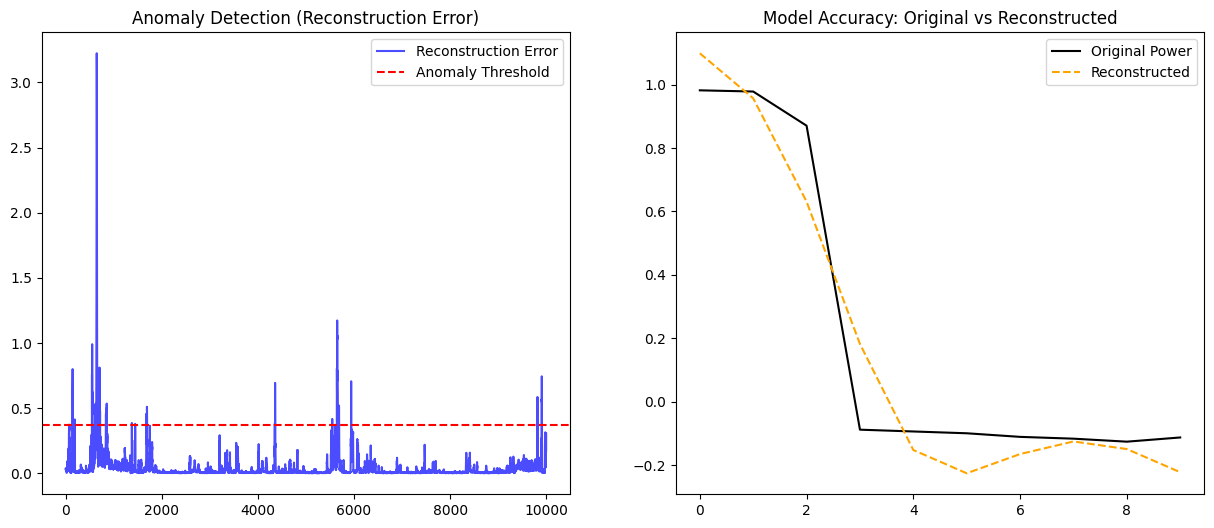

Total Anomalies Found: 131


In [ ]:
# --- 1. CONFIGURATION ---
# Change this to your actual folder path
FILE_PATH = '/content/drive/My Drive/household_power_consumption.txt'
WINDOW_SIZE = 10  # Look at 10 minutes of data at a time
FEATURES = 7      # Global_active_power, Global_reactive_power, Voltage, Global_intensity, Sub_1, Sub_2, Sub_3

# --- 2. DATA LOADING & CLEANING ---
print("Loading dataset...")
# Semicolon separator and '?' handling are crucial for this specific UCI dataset
df = pd.read_csv(FILE_PATH, sep=';', low_memory=False, na_values=['?'])

# Drop Date/Time for the model, drop rows with missing values
df_numeric = df.iloc[:, 2:].dropna().astype(float)

# --- 3. PREPROCESSING ---
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric.values)

# Create Sequences (Windowing)
def create_sequences(data, window):
    x = []
    for i in range(len(data) - window):
        x.append(data[i:i+window])
    return np.array(x)

# Using a subset (first 50,000 rows) for faster training in this example
X = create_sequences(scaled_data[:50000], WINDOW_SIZE)

# Train on 80% (Normal behavior), Test on 20% (to find anomalies)
train_size = int(len(X) * 0.8)
x_train, x_test = X[:train_size], X[train_size:]

# --- 4. BUILD TEMPORAL ATTENTION Bi-LSTM AUTOENCODER ---
def build_attention_model():
    inputs = layers.Input(shape=(WINDOW_SIZE, FEATURES))

    # Encoder: Bidirectional LSTM
    encoder = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(inputs)

    # Temporal Attention Layer
    query = layers.Dense(64)(encoder)
    value = layers.Dense(64)(encoder)
    attention_layer = layers.Attention()([query, value])

    # Bottleneck
    bottleneck = layers.LSTM(16, return_sequences=False)(attention_layer)

    # Decoder
    decoder_input = layers.RepeatVector(WINDOW_SIZE)(bottleneck)
    decoder_lstm = layers.LSTM(32, return_sequences=True)(decoder_input)
    outputs = layers.TimeDistributed(layers.Dense(FEATURES))(decoder_lstm)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

model = build_attention_model()

# --- 5. TRAINING ---
print("Training the model (this will take a few minutes)...")
history = model.fit(x_train, x_train, epochs=100, batch_size=128, validation_split=0.1, verbose=1)

# --- 6. ANOMALY DETECTION & EVALUATION ---
predictions = model.predict(x_test)
mse_per_sample = np.mean(np.square(x_test - predictions), axis=(1, 2))

# Dynamic Threshold: Mean + 3 Standard Deviations
threshold = np.mean(mse_per_sample) + 3 * np.std(mse_per_sample)
anomalies = mse_per_sample > threshold

# --- 7. VISUALIZING RESULTS ---
plt.figure(figsize=(15, 6))

# Plot 1: Reconstruction Error
plt.subplot(1, 2, 1)
plt.plot(mse_per_sample, label='Reconstruction Error', color='blue', alpha=0.7)
plt.axhline(y=threshold, color='red', linestyle='--', label='Anomaly Threshold')
plt.title('Anomaly Detection (Reconstruction Error)')
plt.legend()

# Plot 2: Original vs Reconstructed (Sample 0)
plt.subplot(1, 2, 2)
plt.plot(x_test[0, :, 0], label='Original Power', color='black')
plt.plot(predictions[0, :, 0], label='Reconstructed', color='orange', linestyle='--')
plt.title('Model Accuracy: Original vs Reconstructed')
plt.legend()
plt.show()

print(f"Total Anomalies Found: {np.sum(anomalies)}")

Initializing SHAP Explainer (this takes a moment)...
Calculating SHAP values... please wait.


  0%|          | 0/3 [00:00<?, ?it/s]

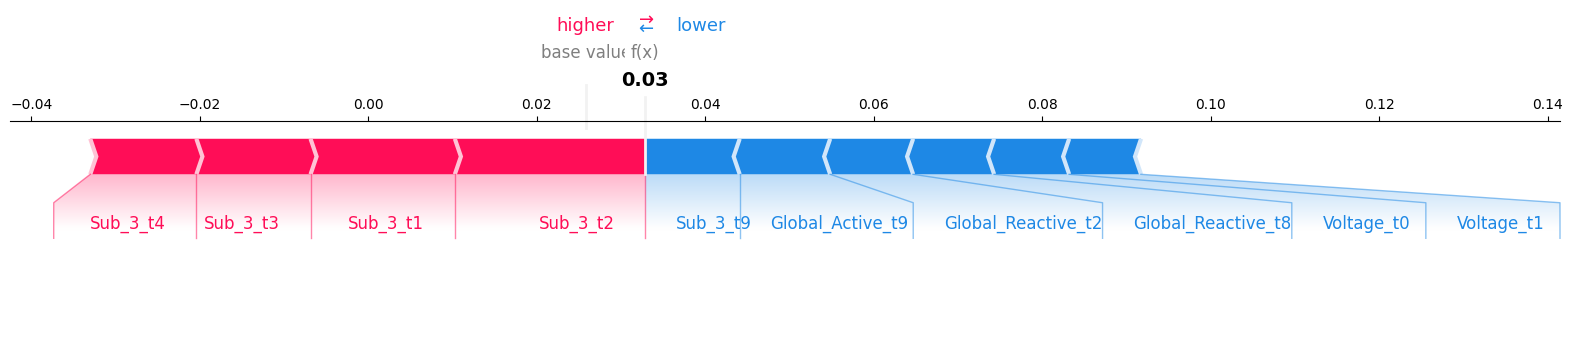

In [ ]:
# 1. Define the wrapper with internal reshaping
def model_error_wrapper(x_flat):
    # SHAP sends data as 2D (Samples, Window*Features)
    # We must reshape it back to 3D (Samples, 10, 7) for the Bi-LSTM
    x_reshaped = x_flat.reshape(-1, WINDOW_SIZE, FEATURES)

    # Convert to tensor for the model
    x_tensor = tf.convert_to_tensor(x_reshaped, dtype=tf.float32)
    preds = model(x_tensor)

    # Calculate Mean Squared Error per sample (Result must be 1D for SHAP)
    # We reduce across axis 1 (time) and 2 (features)
    error = tf.reduce_mean(tf.square(x_tensor - preds), axis=[1, 2])
    return error.numpy()

# 2. Prepare data (Flattening is required for KernelExplainer input)
# Using a smaller background (20-30) makes it run MUCH faster
background_flat = x_train[np.random.choice(x_train.shape[0], 30, replace=False)].reshape(30, -1)
test_samples_flat = x_test[:3].reshape(3, -1)

# 3. Initialize Explainer
print("Initializing SHAP Explainer (this takes a moment)...")
explainer = shap.KernelExplainer(model_error_wrapper, background_flat)

# 4. Calculate SHAP values
print("Calculating SHAP values... please wait.")
shap_values = explainer.shap_values(test_samples_flat)

# 5. Visualization
# Generate feature names for the plot: e.g., 'Voltage_t0', 'Voltage_t1'...
feature_names_list = ['Global_Active', 'Global_Reactive', 'Voltage', 'Intensity', 'Sub_1', 'Sub_2', 'Sub_3']
all_feature_names = [f"{feat}_t{step}" for step in range(WINDOW_SIZE) for feat in feature_names_list]

shap.initjs()
# Plot for the first test sample to see what caused the anomaly
shap.force_plot(explainer.expected_value, shap_values[0], feature_names=all_feature_names, matplotlib=True)

Model saved to: /content/drive/My Drive/SmartGrid_Project_Results/
Scaler saved successfully.
Results CSV saved successfully.
Learning curve plot saved.


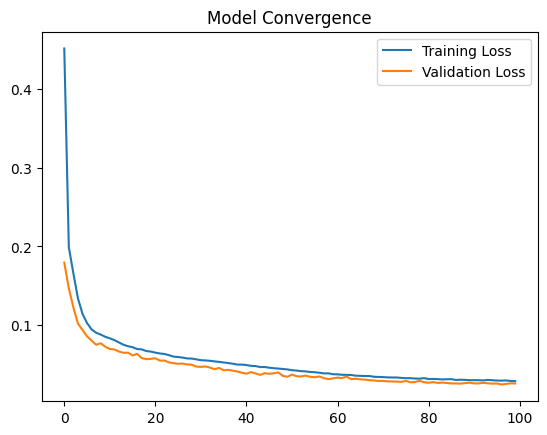

In [ ]:
import joblib
import os

# 1. Create a specific folder in your Drive for this project
save_path = '/content/drive/My Drive/SmartGrid_Project_Results/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 2. Save the Bi-LSTM Model
# Using .keras format is the modern standard for TensorFlow
model.save(save_path + 'bilstm_autoencoder_model.keras')
print(f"Model saved to: {save_path}")

# 3. Save the Scaler
# (You MUST have this to preprocess new data later, or the model won't work)
joblib.dump(scaler, save_path + 'data_scaler.pkl')
print("Scaler saved successfully.")

# 4. Save the Anomaly Results as a CSV
results_df = pd.DataFrame({
    'Reconstruction_Error': mse_per_sample,
    'Is_Anomaly': anomalies
})
results_df.to_csv(save_path + 'anomaly_detection_results.csv', index=False)
print("Results CSV saved successfully.")

# 5. Save the Training History Plot
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Convergence')
plt.legend()
plt.savefig(save_path + 'learning_curve.png')
print("Learning curve plot saved.")

✅ All results successfully saved to: /content/drive/My Drive/SmartGrid_Research_Final/


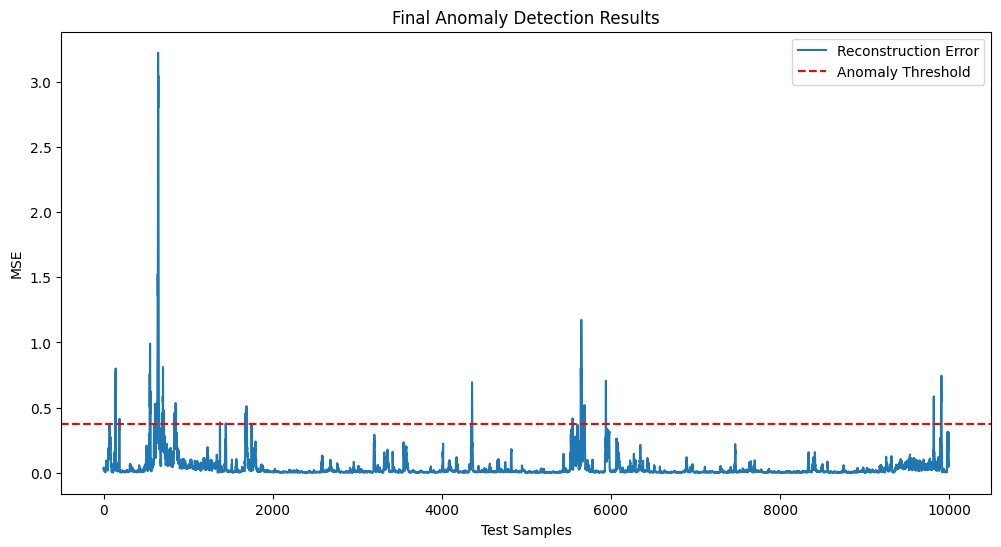

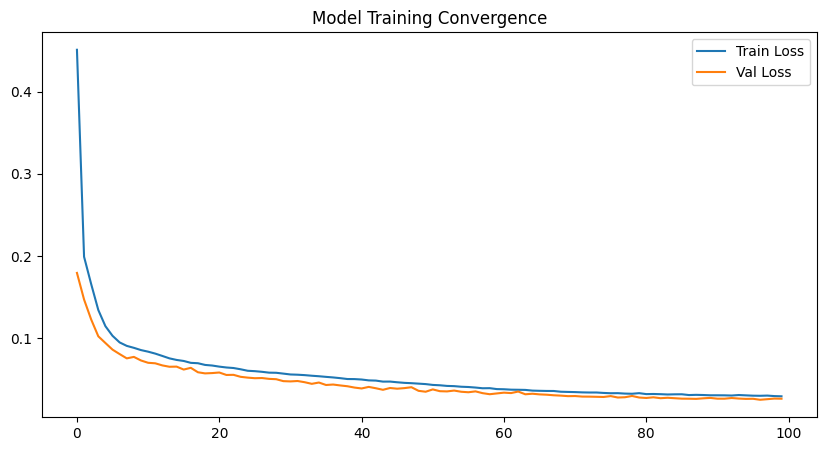

In [ ]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a dedicated results directory in Google Drive
save_dir = '/content/drive/My Drive/SmartGrid_Research_Final/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 2. Save the Model and Scaler
# The .keras format saves the architecture, weights, and optimizer state
model.save(save_dir + 'attention_bilstm_model.keras')
# The scaler is required for any future testing or real-time deployment
joblib.dump(scaler, save_dir + 'data_scaler.pkl')

# 3. Save Quantitative Results to CSV
# This allows you to create tables in Excel or LaTeX easily
results_summary = pd.DataFrame({
    'Sample_Index': range(len(mse_per_sample)),
    'Reconstruction_Error_MSE': mse_per_sample,
    'Is_Anomaly': anomalies.astype(int)
})
results_summary.to_csv(save_dir + 'anomaly_detection_report.csv', index=False)

# 4. Save the Visual Proofs (High-Resolution for Thesis)
# Save the Reconstruction Error Plot
plt.figure(figsize=(12, 6))
plt.plot(mse_per_sample, label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Anomaly Threshold')
plt.title('Final Anomaly Detection Results')
plt.xlabel('Test Samples')
plt.ylabel('MSE')
plt.legend()
plt.savefig(save_dir + 'reconstruction_error_plot.png', dpi=300)

# Save the Learning Curve (Proof of training stability)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Training Convergence')
plt.legend()
plt.savefig(save_dir + 'training_history.png', dpi=300)

print(f"✅ All results successfully saved to: {save_dir}")